## 1. Environment Setup and Model Dependencies

In [1]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)

# Model
from sklearn.ensemble import RandomForestClassifier

plt.style.use("seaborn-v0_8")

# Load processed/cleaned data
df = pd.read_csv("../data/interim/transactions_clean.csv")
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,...,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,time_of_day,day_of_week,is_weekend,is_fraud,log_amount
0,1,1357,20937,720,2024-01-18 19:23:00,18780.52,WALLET,0,Travel,0.243550,...,NONE,0.769328,1,2,0.069502,19,3,0,0,9.840629
1,2,4095,29542,764,2024-03-30 02:22:00,18955.06,CARD,0,Electronics,0.119761,...,OTP,0.468411,1,1,0.010010,2,5,1,0,9.849879
2,3,3618,25236,671,2024-01-04 17:26:00,10743.34,UPI,0,Fashion,0.565367,...,PIN,0.464356,0,1,0.118434,17,3,0,0,9.282134
3,4,2755,29904,624,2024-01-27 16:00:00,5054.75,CARD,0,Utilities,0.843842,...,PIN,0.635799,0,3,0.114947,16,5,1,0,8.528281
4,5,2732,24151,501,2024-02-20 23:14:00,14799.50,CARD,0,Gaming,0.202402,...,OTP,0.684301,2,0,0.014550,23,1,0,0,9.602416


## 2. Feature Engineering and Feature Set Reconstruction

In [2]:
# Ensure engineered features exist
EPS = 1e-6  # small constant to prevent division-by-zero

# Compute customer's average transaction amount
customer_avg = df.groupby("customer_id")["amount"].transform("mean")

# Measure deviation from customer's historical average
df["amount_deviation"] = df["amount"] - customer_avg

In [3]:
# Base 24h velocity
if "velocity_24h" not in df.columns:
    if "txncountlast24h" in df.columns:
        df["velocity_24h"] = df["txncountlast24h"]
    else:
        raise ValueError("Missing base velocity feature: 'velocity_24h' or 'txncountlast24h'")
    
# Derived velocities (only compute if missing)
velocity_defaults = {
    "velocity_1h": df["velocity_24h"] / 6,
    "velocity_7d": df["velocity_24h"] * 3,
}

for col, formula in velocity_defaults.items():
    if col not in df.columns:
        df[col] = formula.round().astype(int)

# Velocity Ratios
ratio_features = {
    "velocity_ratio_1h_24h": ("velocity_1h", "velocity_24h"),
    "velocity_ratio_24h_7d": ("velocity_24h", "velocity_7d"),
}

for new_col, (num, denom) in ratio_features.items():
    if new_col not in df.columns:
        df[new_col] = df[num] / (df[denom] + EPS)

In [4]:
# Device Sharing Feature
if "device_customer_sharing" not in df.columns:
    df["device_customer_sharing"] = (
        df.groupby("device_id")["customer_id"].transform("nunique")
    )

# Combined Risk Index
def safe_normalize(series):
    """
    Normalize a numeric series to [0,1].
    Returns zeros if series is constant or missing.
    """
    max_val = series.max()
    if max_val is None or max_val == 0:
        return pd.Series(0, index=series.index)
    return series / (max_val + EPS)

In [5]:
# Optional behavioral features (fallback to zero if missing)
past_fraud = safe_normalize(df.get("past_fraud_count_customer", pd.Series(0, index=df.index)))
past_disputes = safe_normalize(df.get("past_disputes_customer", pd.Series(0, index=df.index)))
otp_success = df.get("otp_success_rate_customer", pd.Series(0, index=df.index))

df["combined_risk_index"] = (
    0.30 * df["ip_address_risk_score"]
    + 0.20 * (1 - df["device_trust_score"])
    + 0.20 * df["merchant_historical_fraud_rate"]
    + 0.10 * past_fraud
    + 0.10 * past_disputes
    + 0.10 * otp_success
)

In [6]:
feature_cols = [
    "amount",
    "ip_address_risk_score",
    "device_trust_score",
    "velocity_24h",
    "merchant_historical_fraud_rate",
    "amount_deviation",
    "velocity_ratio_1h_24h",
    "velocity_ratio_24h_7d",
    "device_customer_sharing",
    "combined_risk_index",
]

X = df[feature_cols].fillna(0)
y = df["is_fraud"]

## 3. Train–Validation Split and Model Training

In [7]:
# Split dataset while preserving fraud class distribution
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize model
clf = RandomForestClassifier(
    n_estimators=300,              # number of trees
    max_depth=None,                # allow full tree growth
    n_jobs=-1,                     # use all CPU cores
    random_state=42,
    class_weight="balanced_subsample"  # handle class imbalance
)

# Train model
clf.fit(X_train, y_train)

# Predict fraud probability (positive class probability)
y_prob = clf.predict_proba(X_val)[:, 1]

roc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)
print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

ROC AUC: 0.5601
PR AUC: 0.1141


## 4. Precision–Recall Curve Analysis

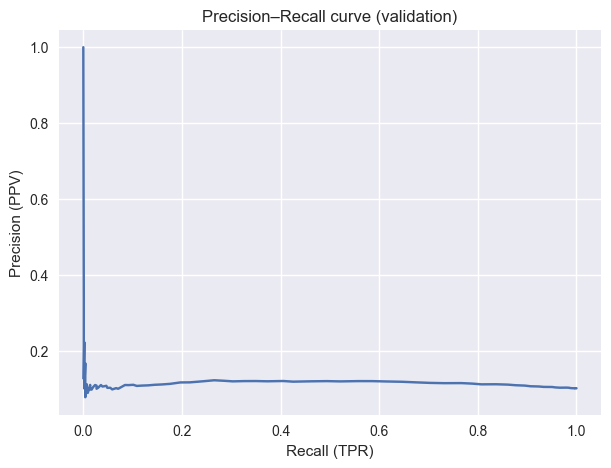

In [8]:
# Compute precision-recall curve values
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

# Plot PR curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall (TPR)")
plt.ylabel("Precision (PPV)")
plt.title("Precision–Recall curve (validation)")
plt.grid(True)
plt.show()

## 5. ROC Curve and AUC Evaluation

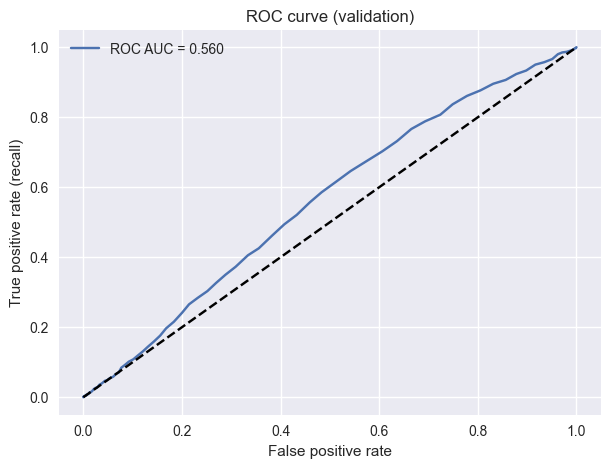

In [9]:
# Compute ROC curve values
fpr, tpr, roc_thresholds = roc_curve(y_val, y_prob)

# Compute AUC score
roc = roc_auc_score(y_val, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve (validation)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Cost-Sensitive Threshold Optimization

In [10]:
# Define business costs (example values)
fraud_cost = 1000    # cost of missed fraud
review_cost = 10     # cost of false alarm / manual review

valid_thresholds = thresholds  # thresholds from PR curve

utilities = []

# Evaluate business utility at each threshold
for th in valid_thresholds:
    y_pred = (y_prob >= th).astype(int)

    tp = ((y_pred == 1) & (y_val == 1)).sum()
    fp = ((y_pred == 1) & (y_val == 0)).sum()
    fn = ((y_pred == 0) & (y_val == 1)).sum()

    # Utility: reward true positives, penalize mistakes
    utility = (tp * fraud_cost) - (fp * review_cost) - (fn * fraud_cost)
    utilities.append(utility)

# Select threshold with maximum utility
best_idx = np.argmax(utilities)
best_threshold = valid_thresholds[best_idx]

## 7. Utility vs Decision Threshold

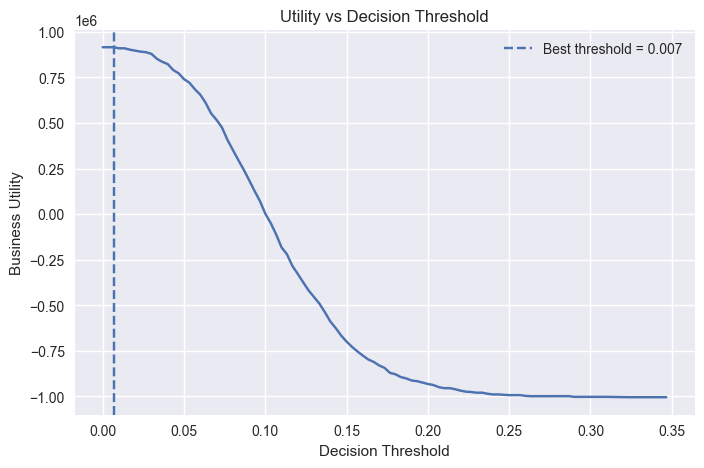

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(valid_thresholds, utilities)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Business Utility")
plt.title("Utility vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

## 8. Metrics at Selected Thresholds

In [12]:
from sklearn.metrics import precision_score, recall_score

def metrics_at_threshold(th):
    """
    Compute precision and recall for a given threshold.
    """
    y_pred = (y_prob >= th).astype(int)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    return prec, rec

candidates = [0.3, 0.5, 0.7, best_threshold]

for th in candidates:
    prec, rec = metrics_at_threshold(th)
    print(f"Threshold={th:.3f} | Precision={prec:.3f} | Recall={rec:.3f}")

Threshold=0.300 | Precision=0.154 | Recall=0.002
Threshold=0.500 | Precision=0.000 | Recall=0.000
Threshold=0.700 | Precision=0.000 | Recall=0.000
Threshold=0.007 | Precision=0.101 | Recall=1.000


## 9. Translating Scores into Operational Policy

In [13]:
# Example policy tiers derived from model calibration and business input
policy = {
    "HARD_BLOCK": 0.9,       # Very high fraud risk
    "OTP_CHALLENGE": 0.7,    # Medium-high risk
    "SOFT_REVIEW": 0.5       # Moderate risk
}

# Example decision logic
def assign_action(prob):
    if prob >= policy["HARD_BLOCK"]:
        return "HARD_BLOCK"
    elif prob >= policy["OTP_CHALLENGE"]:
        return "OTP_CHALLENGE"
    elif prob >= policy["SOFT_REVIEW"]:
        return "SOFT_REVIEW"
    else:
        return "ALLOW"